In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/content/sales_data.csv')

In [45]:
dummy_df = pd.read_csv('/content/sales_data.csv')
dummy_df = dummy_df[['Sale_Date','Sales_Amount']].copy()

In [15]:
df = df[['Sale_Date','Quantity_Sold']].copy()

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sale_Date      1000 non-null   object
 1   Quantity_Sold  1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB


In [46]:
df['Sale_Date'] = df['Sale_Date'].astype('datetime64[ns]')
dummy_df['Sale_Date'] = dummy_df['Sales_Amount'].astype('datetime64[ns]')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Sale_Date      1000 non-null   datetime64[ns]
 1   Quantity_Sold  1000 non-null   int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 15.8 KB


In [18]:
df.isna().sum()

,0
Sale_Date,0
Quantity_Sold,0


In [24]:
# sort the data on basis of date time
df = df.sort_values(by='Sale_Date').reset_index()

In [26]:
df['Sale_Date'].nunique()

340

In [33]:
# drawing the line graph of datetime and unit sold
import plotly.express as px

df_daily_sales = df.groupby('Sale_Date')['Quantity_Sold'].sum().reset_index()

fig = px.line(df_daily_sales, x='Sale_Date', y='Quantity_Sold', title='Daily Quantity Sold Over Time')
fig.show()

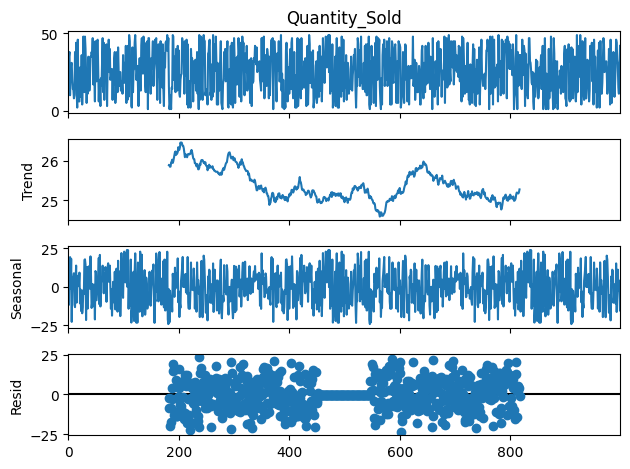

In [34]:
# first let see the decompostion of the time series data
from statsmodels.tsa.seasonal import seasonal_decompose

decompose = seasonal_decompose(df['Quantity_Sold'], period=365)
decompose.plot()
plt.show()

ADF Statistic: -32.103740314845524
p-value: 0.0
Critical Values:
   1%: -3.4369127451400474
   5%: -2.864437475834273
   10%: -2.568312754566378


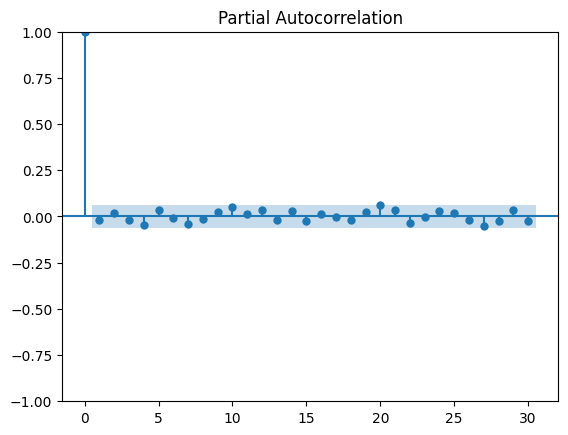

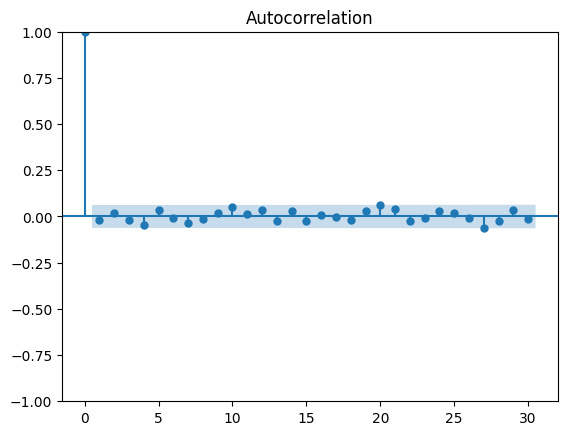

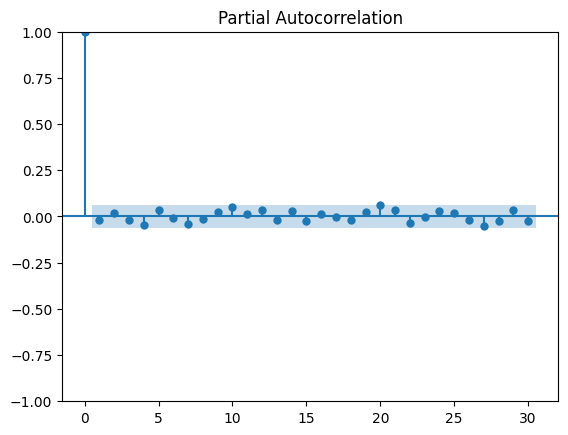

In [38]:
# tests
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

adf = adfuller(df['Quantity_Sold'])
print(f'ADF Statistic: {adf[0]}')
print(f'p-value: {adf[1]}')
print(f'Critical Values:')
for key, value in adf[4].items():
    print(f'   {key}: {value}')

plot_acf(df['Quantity_Sold'])
plot_pacf(df['Quantity_Sold'])

In [41]:
# white noise test
#  Ljung-Box test
from statsmodels.stats.diagnostic import acorr_ljungbox

ljbtest = acorr_ljungbox(df['Quantity_Sold'], lags=2)
print(f'Test Statistic: {ljbtest}')

Test Statistic:     lb_stat  lb_pvalue
1  0.283774   0.594238
2  0.638655   0.726637


In [ ]:
# this dataset is not good for woking their is no pattern we can decode and if we go for forecasting then it would be simple noise nothing more
# thus pure white noise and cannot use any model to predict this

In [51]:
# lets try with sales amount
# ploting the line plot for dummy-df

dummy_df = pd.read_csv('/content/sales_data.csv')
dummy_df = dummy_df[['Sale_Date','Sales_Amount']].copy()
dummy_df['Sale_Date'] = pd.to_datetime(dummy_df['Sale_Date'])

dummy_df_daily_sales = dummy_df.groupby('Sale_Date')['Sales_Amount'].sum().reset_index()

fig = px.line(dummy_df_daily_sales, x='Sale_Date', y='Sales_Amount', title='Daily Sales Amount Over Time')
fig.show()

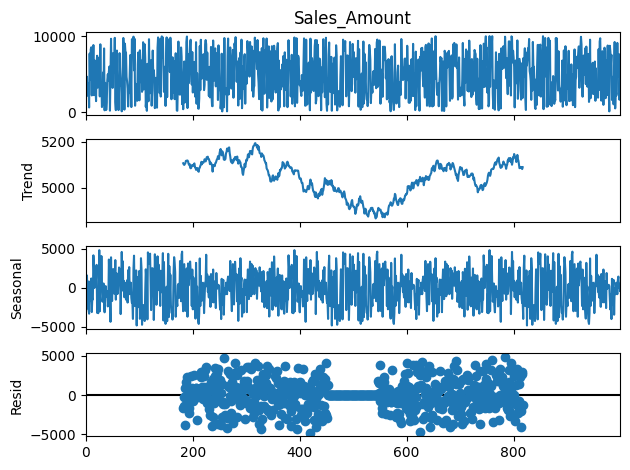

In [52]:
decompose = seasonal_decompose(dummy_df['Sales_Amount'], period=365)
decompose.plot()
plt.show()